In [2]:
import pandas as pd
df = pd.read_csv("resume_data.csv")
df.columns

Index(['Category', 'Resume'], dtype='object')

In [3]:
df.shape

(962, 2)

In [4]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return " ".join(text)

df['cleaned_resume'] = df['Resume'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['cleaned_resume']).toarray()
y = df['Category']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=300)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9948186528497409


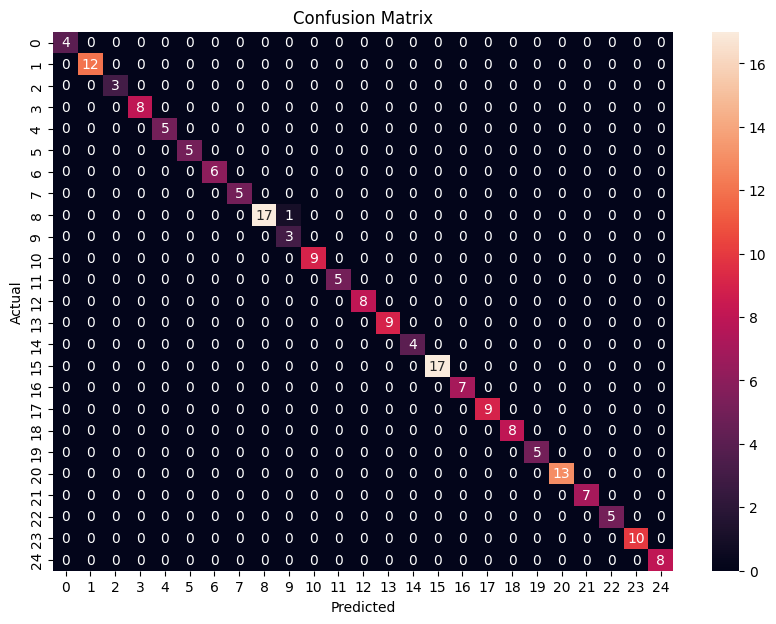

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         5
           8       1.00      0.94      0.97        18
           9       0.75      1.00      0.86         3
          10       1.00      1.00      1.00         9
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         8
          13       1.00      1.00      1.00         9
          14       1.00      1.00      1.00         4
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00         7
          17       1.00    

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

In [ ]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [ ]:
def predict_resume(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned]).toarray()
    prediction = model.predict(vector)
    return le.inverse_transform(prediction)[0]

In [ ]:
sample_resume = "I have experience in Python, machine learning, and data analysis"

print(predict_resume(sample_resume))

Data Science


In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py
# (paste the app.py code I gave earlier)

Overwriting app.py


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3B4TkeU4jDi44SGSeTIC4wAOdKk_4wiHQBtTePAScA2AFPAq3")

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import re

model = pickle.load(open('model.pkl', 'rb'))
tfidf = pickle.load(open('tfidf.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text.lower()

def predict_resume(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned]).toarray()
    prediction = model.predict(vector)
    return le.inverse_transform(prediction)[0]

st.title("AI Resume Screening System")

text = st.text_area("Paste your resume here")

if st.button("Predict"):
    result = predict_resume(text)
    st.success(f"Predicted Category: {result}")

Overwriting app.py


In [ ]:
from pyngrok import ngrok

!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://unda-faye-untreasonable.ngrok-free.dev" -> "http://localhost:8501"
